<a href="https://colab.research.google.com/github/dr-koehler-ai/Clinical-Sepsis-Analysis-Dashboard/blob/main/Sepsis_Dashboard_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'prediction-of-sepsis' dataset.
Dataset downloaded to: /kaggle/input/prediction-of-sepsis
Shape: (1552210, 44)
Columns: ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552210 entries, 0 to 1552209
Data columns (total 44 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1552210 non-null  int64  
 1   Hour              1552210 non-null  int64  
 2   HR                1398811 non-null  float64
 3   O2Sat        

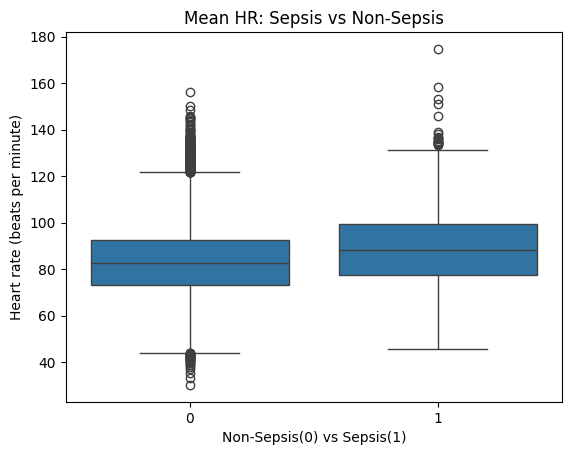

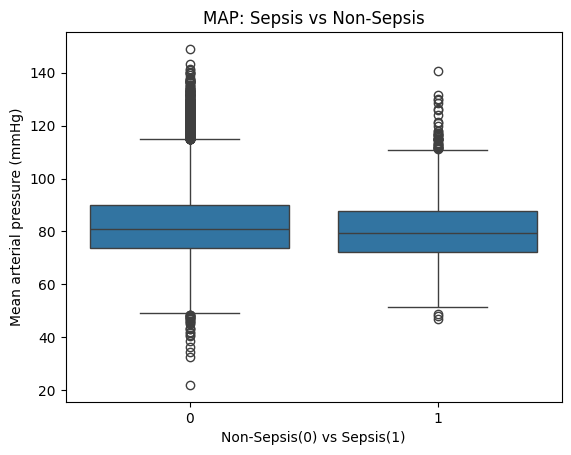

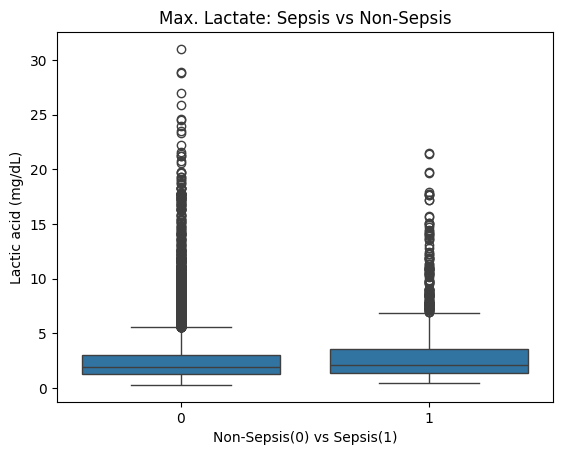

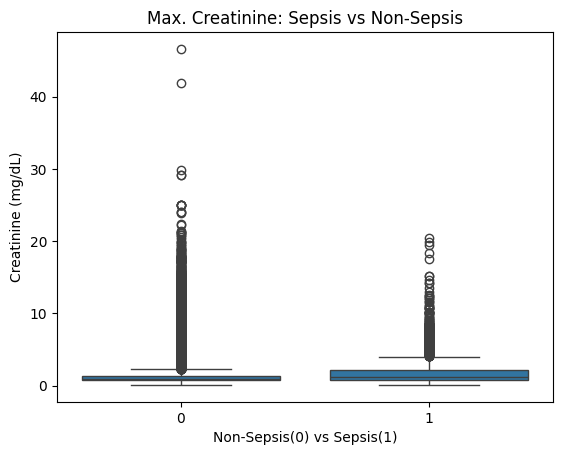


=== Clinical Summary Table ===

                Non_Sepsis     Sepsis
HR_mean          83.390114  89.098635
MAP_mean         82.722173  80.539163
Lactate_max       2.667160   2.997378
Creatinine_max    1.531512   1.930069


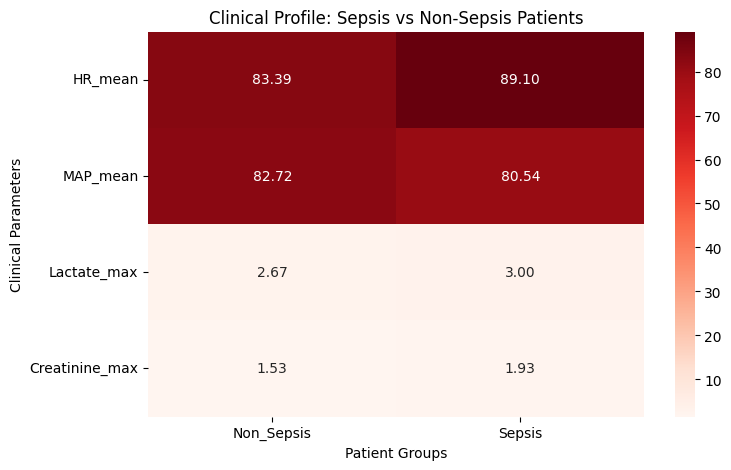

In [80]:
# Clinical Sepsis Analytics Dashboard (V1)
# =========================================

import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# =========================
# 1. Dataset Download
# =========================
dataset_path = kagglehub.dataset_download(
    "salikhussaini49/prediction-of-sepsis"
)

print("Dataset downloaded to:", dataset_path)


# =========================
# 2. Load dataset
# =========================
dataset_raw_df = pd.read_csv(
    "/kaggle/input/prediction-of-sepsis/Dataset.csv"
)

print("\nShape:", dataset_raw_df.shape)
print("\nColumns:", dataset_raw_df.columns.tolist())
print("\nPatients:", dataset_raw_df["Patient_ID"].nunique())


# =========================
# 3. Missing Values Analysis
# =========================
missing = dataset_raw_df.isnull().mean().sort_values(ascending=False)
print("\nTop Missing Values:\n", missing.head(15))


clinical_rel_col = [
    'HR', 'Temp', 'MAP', 'Resp',
    'Creatinine', 'Lactate', 'WBC',
    'Platelets', 'O2Sat'
]

good_cols = missing[missing < 0.9].index
final_cols = list(set(good_cols) | set(clinical_rel_col))

dataset_clean = dataset_raw_df[final_cols]


# =========================
# 4. Patient-level aggregation
# =========================
dataset_agg = dataset_clean.groupby("Patient_ID").agg({
    "HR": ["mean", "max"],
    "O2Sat": ["mean", "min"],
    "Temp": ["mean", "min", "max"],
    "MAP": ["mean", "min"],
    "Resp": ["mean", "max"],
    "Lactate": ["mean", "max"],
    "WBC": ["mean", "max"],
    "Creatinine": "max",
    "Age": "first",
    "Gender": "first",
    "SepsisLabel": "max"
})

# flatten columns
dataset_agg.columns = [
    f"{col[0]}_{col[1]}" if isinstance(col, tuple) else col
    for col in dataset_agg.columns
]

dataset_agg = dataset_agg.rename(columns={"SepsisLabel_max": "SepsisPatient"})


print("\nFinal dataset shape:", dataset_agg.shape)


# =========================
# 5. Boxplots (clinical differences)
# =========================
features_to_plot = [
    ("HR_mean", "Heart Rate"),
    ("MAP_mean", "Mean Arterial Pressure"),
    ("Lactate_max", "Lactate"),
    ("Creatinine_max", "Creatinine")
]

for feature, label in features_to_plot:
    plt.figure()
    sns.boxplot(data=dataset_agg, x="SepsisPatient", y=feature)
    plt.title(f"{label}: Sepsis vs Non-Sepsis")
    plt.xlabel("Sepsis Status (0 = No, 1 = Yes)")
    plt.ylabel(label)
    plt.show()


# =========================
# 6. Summary Table
# =========================
features = ["HR_mean", "MAP_mean", "Lactate_max", "Creatinine_max"]

comparison_df = pd.DataFrame({
    "Non_Sepsis": dataset_agg[dataset_agg["SepsisPatient"] == 0][features].mean(),
    "Sepsis": dataset_agg[dataset_agg["SepsisPatient"] == 1][features].mean()
})

print("\n=== Clinical Summary Table ===\n")
print(comparison_df.round(2))


# =========================
# 7. Final Heatmap
# =========================
plt.figure(figsize=(8, 5))

sns.heatmap(
    comparison_df,
    annot=True,
    cmap="Reds",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Clinical Profile: Sepsis vs Non-Sepsis")
plt.ylabel("Clinical Parameters")
plt.xlabel("Group")
plt.show()